# 04_04 · 未来15分钟预测与评价

本书回答当前实验中的这个问题：**让不同采样方式建立的模型，在同一个整数分钟末，预测随后15分钟的波动，效果有什么差别？**

“共同”指04_01预先给定同一份分钟起点表；不是时间、成交量、成交额采样点的交集，也没有把各自的价格序列重新插到整数分钟上。例如10:00的任务统一对应10:00—10:15这一段实际行情。

| 路径 | 模型直接输出什么 | 本书怎样得到15分钟预测 |
|---|---|---|
| HAR | 针对15分钟目标拟合的去季节性方差率 | 乘回未来15分钟的已知季节暴露 |
| GARCH、FIGARCH | 完整采样区间的条件收益方差 | 推算事件结束位置，再按重叠季节暴露分配 |
| ARFIMA-logRV、ARFIMA-logBPV | 完整采样区间的RV或BPV期望 | 使用同一套事件时间转换 |

**阅读顺序**：1 配置 → 2 加载观测与模型函数 → 3 结果契约和辅助计算 → 4 事件时间转换 → 5 每日预测主循环 → 6 评价。第3、4节中标明“函数定义”的单元格只准备计算方法；第5节才真正恢复状态、逐点预测。若先了解执行流程，可以先读第5节的分段注释，再回看被调用的函数。

RV与BPV分别评价，所有结果均为方差/波动代理尺度，没有开平方或年化。参数来自04_02的6／12个日历月每日拟合，日内固定；时钟、等价粒度和季节窗口的既有对照全部保留。本书只解释并执行当前“共同分钟起点 + 两条预测路径”的设定，没有实现“每个事件点各自起算15分钟”的另一个设定。

输入仍采用既有全快照复权及分钟内插值，属于离线探索；来源分钟可用性检查不能消除全快照复权的回溯性。低成本观测在内存重建，最终预测按fold／交易日集中保存；现有图表保留此前批次的结果，本次注释与分格未重新运行计算。

**阶段阅读导航**：[01_01 主力连续价格](01_01_im_main_continuous.ipynb) → [02_01 BPV季节因子](02_01_im_bpv_intraday_seasonality.ipynb)（[02_02 窗口比较](02_02_im_bpv_window_comparison.ipynb)）→ [03_01 采样时钟与价格](03_01_im_clock_resampling.ipynb)（[03_02 时钟诊断](03_02_im_clock_comparison_diagnostics.ipynb)）→ [04_01 波动观测量](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。括号中的比较与诊断本用于查看对应阶段结果，不是下一阶段的数据生成依赖；最后两本预测相互独立。


## 1. 选择本次读取或预测的范围

下面的单元格立即定位项目目录、导入依赖并设置配置。默认会重新生成所选范围的预测并保存；只看已有结果时设 `READ_RESULTS_ONLY=True`。两种模式都需要前面的观测输入和日参数文件存在。

In [2]:
import pathlib
import sys
# 从当前工作目录向上定位现有项目根目录；后续只读取项目已有输入和研究结果。
project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")
from config.settings import settings

import json
import hashlib
import time
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from IPython.display import display
research_dir = candidate_root / "01_project_collection/JQ_strategy/draft_experiments"
stage_dir = research_dir / "im_volatility_forecasting"
# 这些参数筛选已有实验配置，不会在本书重新估计日参数。
# 手动运行用默认全网格；批次执行时可由注入参数选择一个 fold。
RUN_FOLDS = globals().get("RUN_FOLDS", ["validation_2025h1", "validation_2025h2", "validation_2026h1", "final_2026"])
EVALUATION_START = globals().get("EVALUATION_START", None)
EVALUATION_END = globals().get("EVALUATION_END", None)
RUN_CLOCKS = globals().get("RUN_CLOCKS", ["time", "volume", "money"])
RUN_GRANULARITIES = globals().get("RUN_GRANULARITIES", [5, 10, 15])
RUN_LOOKBACKS = globals().get("RUN_LOOKBACKS", [0, 30, 60, 120, 360])
RUN_WINDOWS = globals().get("RUN_WINDOWS", [6, 12])
# WRITE_OUTPUTS=True：重新预测时按日保存最终结果。
# READ_RESULTS_ONLY=True：读取已完成预测做评价，不进入下面的状态递推与时间转换。
# 只读模式仍会重建低成本观测量，用其输入签名确认现有结果的来源。
WRITE_OUTPUTS = globals().get("WRITE_OUTPUTS", True)
RUN_PROGRESS = globals().get("RUN_PROGRESS", None)
print(sys.executable)

READ_RESULTS_ONLY = globals().get("READ_RESULTS_ONLY", False)


E:\anaconda3\envs\latitude\python.exe


## 2. 加载公共观测量和模型函数

### 2.1 重建观测量：这一格会读取数据

本格先加载04_01中标记的函数定义，再实际调用 `build_volatility_observations`。它在内存返回采样区间、分钟贡献、季节因子、活动量和已有的15分钟标签定义，不重新估计模型，也不创建中间数据文件。

`targets_15m_df` 的起点是09:32—11:15、13:02—14:45，每天208个候选分钟末，另按标签完整性筛选。若起点为10:00，标签取10:01到10:15这15条分钟末贡献记录；同一分钟起点的真实标签对所有采样方式相同。

In [3]:
# 只加载所属 Notebook 中明确标记的定义单元；不执行其运行、落盘或绘图单元。
observation_notebook = json.loads((research_dir / "04_01_im_volatility_observations.ipynb").read_text(encoding="utf-8"))
observation_namespace = {"__name__": "stage04_observation_definitions"}
observation_definition_cells = [cell for cell in observation_notebook["cells"]
    if cell["cell_type"] == "code" and "observation-kernel" in cell.get("metadata", {}).get("tags", [])]
if not observation_definition_cells:
    raise RuntimeError("缺少 observation-kernel 定义单元")
for cell in observation_definition_cells:
    exec(compile("".join(cell["source"]), "04_01_im_volatility_observations.ipynb::observation-kernel", "exec"),
         observation_namespace)
# 上面 exec 只定义函数；这一行才真正读上游数据并在内存构造观测量。
# events_by_fold：各时钟的完整采样区间及有效资格。
# targets_15m_df：独立的整数分钟末起点及其后15分钟真实标签，各时钟共用。
# minute_measures_df / activity_df：同一全局分钟网格上的波动贡献、季节因子与活动量。
observations = observation_namespace["build_volatility_observations"](research_dir, RUN_FOLDS)


final_2026: 274,056 行，合格 240,585 行


validation_2025h1: 205,201 行，合格 181,496 行


validation_2025h2: 239,426 行，合格 211,791 行


validation_2026h1: 258,257 行，合格 227,277 行


### 2.2 加载计算方法：这一格只定义函数

从04_02加载原生模型的恢复、更新、预测函数以及HAR特征和预测函数。这里不执行每日拟合，也尚未读取某一天的参数；参数读取及具体调用都在第5节。

“参数固定”与“状态固定”不同：日内参数不变，但新的完整事件会更新状态。任意分钟起点用的是更新到该时刻的可用状态。

In [4]:
# 此格只加载已在04_02定义的计算函数，不读日参数文件、不拟合、不恢复任何一天的状态。
# 日参数文件在第5节按fold读取；restore_native_state / update_native / forecast_native
# 分别负责用固定日参数重建状态、吸收一个完整事件、预测未来若干事件。
# HAR直接预测15分钟方差率，使用另一组同样在04_02拟合的参数。
fitting_notebook = json.loads((research_dir / "04_02_im_volatility_model_fitting.ipynb").read_text(encoding="utf-8"))
for tag in ["model-kernels", "har-kernels"]:
    kernel_cells = [cell for cell in fitting_notebook["cells"] if cell["cell_type"] == "code"
        and tag in cell.get("metadata", {}).get("tags", [])]
    if not kernel_cells:
        raise RuntimeError(f"缺少拟合 Notebook 定义单元: {tag}")
    for cell in kernel_cells:
        exec(compile("".join(cell["source"]), f"04_02_im_volatility_model_fitting.ipynb::{tag}", "exec"), globals())


## 3. 结果契约与辅助计算

### 3.1 定义结果字段并展示Schema：这一格立即执行

一行对应一个模型配置在一个共同分钟起点对一个目标的预测。`prediction` 是预测值，`actual` 是该15分钟区间事后实现的RV或BPV。原生收益方差模型与ARFIMA-logRV、HAR-RV对照RV；ARFIMA-logBPV、HAR-BPV对照BPV。

`predicted_clock_steps`、`actual_clock_steps` 是活动量除以采样阈值的步数当量，可能是小数，不是完整事件的整数个数。

In [5]:
# 一行 = 一个配置在一个共同分钟起点对一个RV或BPV目标的预测。
# prediction、actual 都在 log收益平方尺度；本书没有开平方或年化。
# 无法预测仍保留这一行和status，prediction用null表示。
prediction_schema = pa.schema([
    pa.field("fold_id", pa.string(), False),
    pa.field("fit_date", pa.date32(), False),
    pa.field("clock", pa.string(), False),
    pa.field("equivalent_minutes", pa.int16(), False),
    pa.field("seasonality_lookback", pa.int16(), False),
    pa.field("fit_window_months", pa.int16(), False),
    pa.field("model", pa.string(), False),
    pa.field("target", pa.string(), False),
    pa.field("horizon", pa.string(), False),
    pa.field("origin_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("target_end_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("prediction", pa.float64()),
    pa.field("actual", pa.float64()),
    pa.field("status", pa.string(), False),
    # information_age：起点距最后一个合格已完成事件结束的分钟数。
    # predicted/actual_clock_steps：活动量除以采样阈值的“步数当量”，允许小数；
    # 它们不是实际完成的整数事件数量。HAR不走事件转换，所以这两列为空。
    pa.field("information_age_minutes", pa.float64()),
    pa.field("predicted_clock_steps", pa.float64()),
    pa.field("actual_clock_steps", pa.float64()),
    pa.field("prediction_seconds", pa.float64()),
    # 当前未完成物理事件已消耗的阈值比例；来自起点之前已实现的活动量。
    pa.field("current_event_progress", pa.float64()),
], metadata={b"schema_version": b"1.0.0", b"variance_unit": b"log_return_squared",
             b"research_scope": b"offline retrospective price snapshot; RV and BPV are separate targets"})
prediction_keys = ["fold_id", "fit_date", "clock", "equivalent_minutes",
    "seasonality_lookback", "fit_window_months", "model", "target", "horizon", "origin_at", "target_end_at"]
display(pd.DataFrame([{"field": f.name, "type": str(f.type), "nullable": f.nullable}
                      for f in prediction_schema]))



,field,type,nullable
0,fold_id,string,False
1,fit_date,date32[day],False
2,clock,string,False
3,equivalent_minutes,int16,False
4,seasonality_lookback,int16,False
5,fit_window_months,int16,False
6,model,string,False
7,target,string,False
8,horizon,string,False
9,origin_at,"timestamp[us, tz=Asia/Shanghai]",False


### 3.2 定义按日保存与损失汇总方法

`write_prediction_day` 在第5节每日预测结束时调用，保存最终逐点结果。`score_prediction_day` 在重新预测和只读结果两个分支都会调用。

损失只在成功预测上计算，覆盖率分母保留失败起点。QLIKE和MSE先在一天内求均值，最后再按日等权汇总。

In [ ]:
def write_prediction_day(prediction_df, output_path, input_signature):
    """原子提交一天的预测研究结果；不持久化模型状态数组。"""
    if prediction_df.duplicated(prediction_keys).any():
        raise ValueError("预测主键重复")
    # 显式Schema保留字段类型和缺失值；参数/输入签名随最终结果一起保存。
    prediction_table = pa.Table.from_pandas(prediction_df, schema=prediction_schema, preserve_index=False, safe=True)
    prediction_table = prediction_table.replace_schema_metadata({
        **prediction_schema.metadata, b"input_signature": input_signature.encode(),
        b"primary_key": ",".join(prediction_keys).encode()})
    prediction_table.validate(full=True)
    for field in prediction_schema:
        if not field.nullable and prediction_table[field.name].null_count:
            raise ValueError(f"不可空字段缺失: {field.name}")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    # 同目录临时写入并逐值复读后替换目标文件；退出时清理临时文件。
    temporary_path = output_path.with_suffix(".parquet.tmp")
    try:
        pq.write_table(prediction_table, temporary_path, compression="zstd")
        checked_table = pq.ParquetFile(temporary_path).read()
        if not checked_table.equals(prediction_table) or not checked_table.schema.equals(prediction_table.schema, check_metadata=True):
            raise ValueError("预测结果复读不一致")
        os.replace(temporary_path, output_path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()

def score_prediction_day(prediction_df):
    """按一天和相同目标汇总，并保留缺失预测的覆盖分母。"""
    scored_df = prediction_df.copy()
    # 损失只使用成功、有限且为正的预测；真实RV/BPV允许为零。
    # origins统计所有候选行，forecasts只统计有效行，失败不会从覆盖率分母消失。
    valid = ((scored_df["status"] == "ok") & np.isfinite(scored_df["prediction"])
             & (scored_df["prediction"] > 0) & np.isfinite(scored_df["actual"])
             & (scored_df["actual"] >= 0))
    scored_df["valid_prediction"] = valid.astype(int)
    scored_df["qlike"] = np.nan
    scored_df["squared_error"] = np.nan
    # QLIKE = log(h) + y/h；这里只在同一个目标内比较，数值越小越好。
    scored_df.loc[valid, "qlike"] = (np.log(scored_df.loc[valid, "prediction"])
        + scored_df.loc[valid, "actual"] / scored_df.loc[valid, "prediction"])
    scored_df.loc[valid, "squared_error"] = (scored_df.loc[valid, "actual"]-scored_df.loc[valid, "prediction"])**2
    # 代理残差 y/h-1：描述波动预测偏高/偏低，不是收益模型的标准化收益残差。
    scored_df["relative_error"] = np.nan
    scored_df.loc[valid,"relative_error"] = scored_df.loc[valid,"actual"]/scored_df.loc[valid,"prediction"]-1.
    # 先按日和配置汇总；第6节再对每日损失等权平均。
    group_columns = prediction_keys[:9]
    summary_df = scored_df.groupby(group_columns, dropna=False, observed=True).agg(
        origins=("status", "size"), forecasts=("valid_prediction", "sum"),
        qlike=("qlike", "mean"), mse=("squared_error", "mean"),
        information_age_minutes=("information_age_minutes", "mean"),
        prediction_seconds=("prediction_seconds", "sum"),
        mean_prediction=("prediction", "mean"),mean_actual=("actual", "mean"),
        event_progress=("current_event_progress", "mean"),
        predicted_steps=("predicted_clock_steps", "mean"),actual_steps=("actual_clock_steps", "mean")).reset_index()
    with np.errstate(divide="ignore",invalid="ignore"):
        residual_df = scored_df.groupby(group_columns,observed=True)["relative_error"].agg(
            relative_error_bias="mean",relative_error_lag1=lambda values: values.autocorr()
            if values.notna().sum()>=5 and values.std()>0 else np.nan).reset_index()
    return summary_df.merge(residual_df,on=group_columns,validate="one_to_one")



### 3.3 定义模型能接收的观测序列

`eligible_series` 选出该时钟、粒度、季节窗口的合格事件；`model_values` 将其变为模型所需的去季节性输入。第5节使用相同方法取得训练历史和日内更新观测。

保留物理采样点的完整表另有用途：定位当前事件边界。它与这里筛选出的“可送入模型的事件序列”并不是同一张表。

In [ ]:
def eligible_series(event_df, clock, equivalent_minutes, lookback):
    # 先按04_01给出的区间资格筛选，再要求本季节性窗口有正的历史因子。
    # 无效事件不送进模型，也不把删除后两端的价格重新差分成一个新事件。
    selected_df = event_df.loc[(event_df["clock"] == clock)
        & (event_df["equivalent_minutes"] == equivalent_minutes) & event_df["eligible"]].copy()
    selected_df["seasonal_factor"] = (1.0 if lookback == 0 else selected_df[f"seasonality_{lookback}"])
    selected_df = selected_df.loc[np.isfinite(selected_df["seasonal_factor"]) & (selected_df["seasonal_factor"] > 0)]
    return selected_df.sort_values(["sample_at", "split", "sample_number"]).reset_index(drop=True)

def model_values(selected_df, model, target):
    # GARCH/FIGARCH观察去季节性的事件收益；ARFIMA/HAR观察去季节性的RV或BPV。
    # 因子处于方差尺度，所以收益除以平方根、波动代理直接除以因子。
    if model in ("GARCH", "FIGARCH"):
        return selected_df["log_return"].to_numpy(float) / np.sqrt(selected_df["seasonal_factor"].to_numpy(float))
    return selected_df[target].to_numpy(float) / selected_df["seasonal_factor"].to_numpy(float)




### 3.4 定义两种共同样本比较

- `paired_history_window_scores`：固定其他配置，只比较半年和一年都成功的同一起点。
- `common_configuration_scores`：本书传入 `same_clock=False`，在所有所选轴、粒度、模型、季节窗口和历史窗口之间取共同成功起点。

RV和BPV各自取交集。若一个配置失败导致共同样本为空，保留这个结果，不悄悄移除该配置。

In [ ]:
def paired_history_window_scores(prediction_df):
    """同一真实起点上成对比较半年/一年，避免缺失预测改变样本。"""
    # 只移除历史窗口这一维，其余配置、起点和目标末端必须完全相同。
    matching_keys = [key for key in prediction_keys if key != "fit_window_months"]
    valid = prediction_df.loc[(prediction_df["status"] == "ok")
        & np.isfinite(prediction_df["prediction"]) & (prediction_df["prediction"] > 0)
        & np.isfinite(prediction_df["actual"]) & (prediction_df["actual"] >= 0)].copy()
    halves = valid.loc[valid["fit_window_months"] == 6]
    years = valid.loc[valid["fit_window_months"] == 12]
    paired = halves.merge(years,on=matching_keys,suffixes=("_6m","_12m"),validate="one_to_one")
    if paired.empty:
        return pd.DataFrame()
    if not np.allclose(paired["actual_6m"],paired["actual_12m"],rtol=0,atol=0):
        raise ValueError("半年/一年标签不一致")
    y = paired["actual_6m"]
    paired["qlike_12m_minus_6m"] = (np.log(paired["prediction_12m"])+y/paired["prediction_12m"]
        - np.log(paired["prediction_6m"])-y/paired["prediction_6m"])
    paired["mse_12m_minus_6m"] = ((y-paired["prediction_12m"])**2-(y-paired["prediction_6m"])**2)
    groups = [key for key in matching_keys if key not in ("origin_at","target_end_at")]
    return paired.groupby(groups,observed=True,dropna=False).agg(
        common_origins=("qlike_12m_minus_6m","size"),
        qlike_12m_minus_6m=("qlike_12m_minus_6m","mean"),
        mse_12m_minus_6m=("mse_12m_minus_6m","mean")).reset_index()

def common_configuration_scores(prediction_df, same_clock):
    """RV/BPV分别取所有待比较配置共同成功的起点；失败配置不被悄悄排除。"""
    # 本书调用时same_clock=False：在所有轴/粒度/模型/窗口之间取共同成功起点。
    # RV与BPV分别求交集；same_clock=True分支供下一采样步口径保留。
    group_keys = ["fold_id","fit_date","target"]
    if same_clock:
        group_keys += ["clock","equivalent_minutes"]
    frames = []
    configuration_keys = ["clock","equivalent_minutes","seasonality_lookback","fit_window_months","model"]
    origin_keys = ["origin_at","target_end_at"]
    for _, group_df in prediction_df.groupby(group_keys,observed=True):
        # 配置总数在筛掉失败之前确定，保证失败配置不会被悄悄移出比较集合。
        n_configurations = len(group_df[configuration_keys].drop_duplicates())
        valid = group_df.loc[group_df["status"].eq("ok") & np.isfinite(group_df["prediction"])
            & group_df["prediction"].gt(0) & np.isfinite(group_df["actual"])].copy()
        common = valid.groupby(origin_keys,observed=True).size()
        common = common.loc[common.eq(n_configurations)].rename("_count").reset_index()
        if len(common):
            selected = valid.merge(common[origin_keys],on=origin_keys,validate="many_to_one")
            frames.append(score_prediction_day(selected))
    return pd.concat(frames,ignore_index=True) if frames else pd.DataFrame()



### 3.5 定义状态恢复与结果复用的身份检查

`validate_native_training` 核对恢复历史与当天拟合所用的样本数量、取值及时间顺序。`prediction_day_signature` 将当天日参数与本折观测输入绑定，用于确认已有预测属于同一批输入；它不是Notebook代码的版本哈希。

In [ ]:
def validate_native_training(fit,training_df,values):
    # 日初恢复必须使用拟合时完全相同的值和时间顺序；数量与摘要同时核对。
    if len(values)!=fit.n_obs:
        raise ValueError("恢复历史样本数与日参数不符")
    digest=hashlib.sha256(np.ascontiguousarray(values).tobytes())
    digest.update(pd.DatetimeIndex(training_df["sample_at"]).as_unit("us").asi8.tobytes())
    if digest.hexdigest()!=fit.training_digest:
        raise ValueError("恢复历史摘要与训练样本不符")

def prediction_day_signature(fold_id,fit_date,all_fits_df):
    day_df=all_fits_df.loc[all_fits_df["fit_date"].eq(fit_date)].sort_values(
        ["clock","equivalent_minutes","seasonality_lookback","fit_window_months","model","target","horizon"]).reset_index(drop=True)
    # 签名绑定本fold的输入以及当天全部日参数；追加其他日期不使本日结果失效。
    # 此处不是对Notebook源代码本身做哈希。
    serialized=day_df.to_json(orient="records",date_format="iso",double_precision=15)
    return hashlib.sha256(("04-predict-source-visible-v1|"+observations["manifest"]["fold_input_manifest_ids"][fold_id]+serialized).encode()).hexdigest()


## 4. 定义事件到15分钟的转换

这一节的三个函数在第5节原生模型分支中调用；HAR直接预测分支不需要这条转换路径。它们分别做：分钟积分 → 推算完整事件边界 → 分配整事件波动。

### 4.1 分钟积分：`integrated_minutes`

输入是一串每分钟的贡献和区间的两个交易分钟坐标。完整分钟全取，首尾不足一分钟时按覆盖比例取；它不决定预测起点，也不负责预测波动。

第i个源分钟占据坐标 `[i,i+1]`，其分钟末是 `i+1`。休市不增加坐标，因此跨交易时段的资格由后面的边界检查负责。

In [6]:
def integrated_minutes(values, start, end):
    """在全局交易分钟坐标上积分；values 是每个真实分钟的贡献/已知季节因子。"""
    # values[i]是第i个真实分钟的整分钟贡献；start/end用交易分钟坐标，支持小数。
    # 第i个分钟占[i,i+1]，该分钟收盘位置是i+1；休市不增加这个坐标。
    # 本函数只积分调用方传入的数组；传实际活动还是预测活动由第5节决定。
    if not (np.isfinite(start) and np.isfinite(end) and end > start):
        raise ValueError("积分区间无效")
    left, right = int(np.floor(start)), int(np.ceil(end))
    indices = np.arange(left, right, dtype=int)
    # 完整覆盖一分钟权重为1，半分钟为0.5；不在这里插值价格或平方收益。
    weights = np.maximum(0., np.minimum(end, indices+1.)-np.maximum(start, indices))
    selected = np.asarray(values)[indices]
    # 有正覆盖权重的分钟必须有值；只落在区间端点的零权重缺失不影响积分。
    if not np.isfinite(selected[weights > 1e-10]).all():
        return np.nan
    return float(np.dot(weights, np.nan_to_num(selected)))



### 4.2 推算未来完整事件：`predict_event_path`

此函数处理的是**当前实现所需的事件预测时间转换**，不是计算真实15分钟标签所需的首尾分钟比例分配。

| 输入 | 含义与可用时点 |
|---|---|
| `start_coordinate` | 当前已可见的最近物理采样点，即尚未完成事件的起点 |
| `origin_coordinate` / `target_end_coordinate` | 当前分钟末／之后15分钟末 |
| `sampling_unit` | 03在该fold开始前校准并冻结的时钟阈值 |
| `actual_activity` | 只在事件起点至当前起点之间取实际活动，确定已完成进度 |
| `expected_activity` | origin之后使用的预计活动；过去20个完整交易日同一分钟位置的均值，日初冻结 |

例如一个事件需要1000手，当前已经完成400手，函数便按预计未来速度推算剩余600手何时完成。随后继续推算后续事件，直到最后一个完整事件覆盖15分钟末端。返回的是预计边界；若尾事件预计超出本交易时段，则返回失败状态。

In [ ]:
def predict_event_path(start_coordinate, origin_coordinate, target_end_coordinate,
                       session_start_coordinate, session_end_coordinate, sampling_unit,
                       actual_activity, expected_activity):
    """已知事件进度 + 历史活动曲线，推算完整事件路径；无未来实值参与。"""
    # start：最近一个已可见物理采样点，即当前未完成事件的起点。
    # origin：本次共同分钟末；target_end：origin之后15分钟。
    # 当前事件必须从本时段前两分钟之后开始，才满足本实现的开场边界约束。
    if start_coordinate < session_start_coordinate+2-1e-8:
        return None, "current_interval_boundary"
    if origin_coordinate < start_coordinate-1e-8 or target_end_coordinate > session_end_coordinate+1e-8:
        return None, "session_boundary"
    # 只有[事件起点,当前预测起点]使用已实现的实际活动；这里不读取未来活动。
    # 例如阈值1000手、到当前已成交400手，progress=0.4，还差600手才结束事件。
    elapsed_clock = (0. if abs(start_coordinate-origin_coordinate) < 1e-8
                     else integrated_minutes(actual_activity, start_coordinate, origin_coordinate))
    progress = elapsed_clock/sampling_unit
    if not np.isfinite(progress) or progress < -1e-7 or progress >= 1+1e-7:
        return None, "clock_progress_mismatch"
    # 仅处理浮点容差：进度应在[0,1)内；明显不匹配的物理时钟返回失败。
    progress = min(max(progress, 0.), 1.-1e-12)
    # origin/session_end都是分钟末整数坐标。
    # 此后只用expected_activity：当日日初冻结的历史同槽均值，时间轴则恒为1。
    origin_index = int(round(origin_coordinate))
    end_index = int(round(session_end_coordinate))
    rates = np.asarray(expected_activity[origin_index:end_index], float)
    if not np.isfinite(rates).all() or np.any(rates < 0):
        return None, "activity_forecast_missing"
    cumulative = np.r_[0., np.cumsum(rates)]
    future_total = integrated_minutes(expected_activity, origin_coordinate, target_end_coordinate)
    # 最后一个预测事件必须覆盖15分钟目标末端，所以向上取整。
    # count是需要预测的完整事件个数，包含当前尚未结束的第一个事件。
    count = max(1, int(np.ceil(progress + future_total/sampling_unit-1e-10)))
    if count > 256:
        return None, "forecast_horizon_limit"
    intervals = []
    previous = float(start_coordinate)
    # 从当前位置累计“预计未来活动”直到依次触达阈值，再在命中的分钟内部
    # 按预计活动匀速分配结束位置。返回的是推算边界，不是未来实际采样边界。
    for step in range(count):
        required = (step+1-progress)*sampling_unit
        # 即使目标的15分钟仍在交易时段内，覆盖它的尾事件也可能预计跨休市。
        # 当前实现遇到这种情况整次转换失败，不只截掉尾事件继续给出预测。
        if required > cumulative[-1]+1e-8:
            return None, "predicted_interval_crosses_session"
        minute = int(np.searchsorted(cumulative, required, side="left")-1)
        minute = max(0,min(minute,len(rates)-1))
        if rates[minute] <= 0:
            return None, "zero_predicted_activity"
        endpoint = origin_coordinate+minute+(required-cumulative[minute])/rates[minute]
        intervals.append((previous,float(endpoint)))
        previous = float(endpoint)
    if previous < target_end_coordinate-1e-7:
        return None, "predicted_path_incomplete"
    # intervals第一段从原事件起点开始，包含origin以前已经过去的部分。
    # 下一函数只取每段与[origin,target_end]重叠的波动；actual未来活动未进入本函数。
    return {"intervals":intervals, "progress":progress,
            "predicted_clock_steps":future_total/sampling_unit}, "ok"



### 4.3 分配整事件预测：`allocate_event_forecasts`

模型给出的每个值覆盖一个**完整采样事件**；本函数只分配其中与目标15分钟重叠的部分。分配比例使用历史季节曲线的积分；没有季节调整时就等于时间长度之比。

以10:00—10:15为目标，假设上一步推算出以下事件边界，且季节因子全为1：

| 预计完整事件 | 整事件预测 | 计入目标的部分 |
|---|---|---|
| 09:58—10:04 | h₁ | h₁ × 4/6 |
| 10:04—10:12 | h₂ | h₂ |
| 10:12—10:20 | h₃ | h₃ × 3/8 |

这只是说明算法的例子，表中结束时间均为预计值。最终预测是三段贡献之和。第一段已过去的两分钟不计入目标，但当前模型也没有用这两分钟的部分事件收益重新估计剩余方差；这是该转换方法的近似。

In [ ]:
def allocate_event_forecasts(normalized_forecasts, path, seasonal_values, origin_coordinate, target_end_coordinate):
    """整事件方差先还原，再按预计季节暴露比例分配，不将部分收益送进原生模型。"""
    # normalized_forecasts按事件顺序给出整段波动预测，尚未乘回季节因子。
    # 第一步h是“当前完整事件”的预测，不是已条件化于部分事件收益的剩余方差。
    # 本函数仅按预计区间的季节暴露比例分配，属于现有实验的时间转换近似。
    estimate = 0.
    for prediction, (start,end) in zip(normalized_forecasts, path["intervals"]):
        overlap_start,overlap_end = max(start,origin_coordinate), min(end,target_end_coordinate)
        if overlap_end <= overlap_start:
            continue
        # 与训练口径一致：每个整事件先乘回其起点的历史季节因子。
        # 整数坐标对应上一分钟末的槽；小数坐标对应它所在的分钟槽。
        at_integer = abs(start-round(start)) < 1e-8
        slot = int(round(start))-1 if at_integer else int(np.floor(start))
        start_factor = float(seasonal_values[slot])
        # exposure为预计完整事件的季节因子积分；overlap仅积分未来15分钟内的部分。
        # 无季节性时因子全为1，比值就退化为“重叠分钟数/预计整事件分钟数”。
        exposure = integrated_minutes(seasonal_values,start,end)
        overlap = integrated_minutes(seasonal_values,overlap_start,overlap_end)
        if not np.isfinite([start_factor, exposure, overlap]).all() or min(start_factor,exposure) <= 0:
            return np.nan
        # 每段贡献 = 去季节性整事件预测 × 起点因子 × 重叠暴露/整段暴露。
        # 这里没有使用未来已实现RV/BPV，也没有把部分事件收益送入原生模型。
        estimate += float(prediction)*start_factor*overlap/exposure
    return estimate


## 5. 实际执行每日预测

### 先准备同一套分钟坐标和结果容器

下面这格立即执行，整理分钟波动、分钟活动及15分钟目标。后续数组都按同一个全局分钟索引定位，避免把某一时钟的“第几个采样点”误当成“第几个真实分钟”。

In [7]:
# 先把三种公共输入放在同一个全局分钟网格上，供下面的日循环使用。
# 此格只准备数组和容器；按日生成预测从下一格的for fold_id开始。
minute_df = observations["minute_measures_df"].sort_values("source_minute_index").reset_index(drop=True)
activity_df = observations["activity_df"].sort_values("source_minute_index").reset_index(drop=True)
# 预测起点直接来自04_01的targets_15m_df，不是各事件时间戳的交集。
# 候选起点：09:32—11:15、13:02—14:45，每分钟一个，再由eligible筛选。
# 例如10:00这一行的actual，累加10:01至10:15这15个分钟末记录的贡献。
target_df = observations["targets_15m_df"].copy()
minute_df["bar_at"] = pd.to_datetime(minute_df["bar_at"])
activity_df["bar_at"] = pd.to_datetime(activity_df["bar_at"])
target_df["origin_at"] = pd.to_datetime(target_df["origin_at"])
target_df["target_end_at"] = pd.to_datetime(target_df["target_end_at"])
if len(minute_df) != len(activity_df) or not minute_df["bar_at"].equals(activity_df["bar_at"]):
    raise ValueError("分钟活动与波动观测的全局索引不一致")
minute_times = pd.DatetimeIndex(minute_df["bar_at"]).as_unit("ns").asi8
activity_df["minute_slot"] = activity_df["bar_at"].dt.hour*60+activity_df["bar_at"].dt.minute
activity_dates = sorted(activity_df["trading_date"].unique())
# 这三个数组含整个快照的实际活动，但预测路径只截取origin以前已实现的部分。
# origin以后的实际活动在主循环中另作actual_steps_diagnostic，绝不传给预测速度。
actual_activity = {"time": np.ones(len(activity_df)),
    "volume": activity_df["all_contract_volume"].to_numpy(float),
    "money": activity_df["all_contract_money"].to_numpy(float)}
# 以下仅在内存累计日摘要/状态统计；WRITE_OUTPUTS=False时也保留逐点预测供本次查看。
daily_score_frames = []
common_score_frames = []
paired_score_frames = []
status_counts = []
fifteen_memory_frames = []


### 再按 fold → 日期 → 模型配置 → 分钟起点执行

下面保留一个连续的主循环，内部注释按5.1—5.7标出步骤，便于顺着实际控制流阅读：

1. 读取本折日参数，核对其观测来源；只读模式直接汇总已有结果。
2. 取得当天共同目标，估计并冻结当日活动速度曲线。
3. 为一个配置恢复日初模型状态；随后按顺序遍历全部分钟起点。
4. 每到一个起点，先吸收该时刻已经完成且源分钟已收盘的事件。
5. HAR直接预测15分钟；原生模型先推算事件路径，再分配整事件波动。
6. 记录预测、真实标签和失败原因；未来实际活动仅记入转换诊断。
7. 全部配置完成后汇总并按日保存。

`pointer` 保证一个配置内每个已完成事件只吸收一次。`state` 是该配置当天递推的状态；`payload` 是当天固定参数；`target` 是当前共同起点及其事后评价标签。

In [ ]:
# 执行顺序：fold → 日参数日期 → 模型配置 → 当日共同分钟起点。
# 原生模型每个配置每日恢复一次状态；内层起点循环沿时间递推，不逐点重新拟合。
for fold_id in RUN_FOLDS:
    event_df = observations["events_by_fold"][fold_id].copy()
    for column in ["sample_at", "previous_sample_at", "source_minute_at"]:
        event_df[column] = pd.to_datetime(event_df[column])
    # 5.1 读取该fold已有的日参数。native参数来自04_02，可与04_03复用；
    # HAR这里只选15m专用参数。input_sha256不一致时停止，避免混用另一批输入。
    fit_path = stage_dir/f"daily_fits_{fold_id}.parquet"
    fit_df = pq.ParquetFile(fit_path).read().to_pandas()
    if not fit_df["input_sha256"].eq(observations["manifest"]["fold_input_manifest_ids"][fold_id]).all():
        raise ValueError("日参数输入身份与当前观测不一致，请回到拟合环节")
    all_fits_df = fit_df.copy()
    fit_df = fit_df.loc[fit_df["horizon"].isin(["native","15m"])
        & fit_df["clock"].isin(RUN_CLOCKS)
        & fit_df["equivalent_minutes"].isin(RUN_GRANULARITIES)
        & fit_df["seasonality_lookback"].isin(RUN_LOOKBACKS)
        & fit_df["fit_window_months"].isin(RUN_WINDOWS)]
    if EVALUATION_START:
        fit_df = fit_df.loc[pd.to_datetime(fit_df["fit_date"]) >= pd.Timestamp(EVALUATION_START)]
    if EVALUATION_END:
        fit_df = fit_df.loc[pd.to_datetime(fit_df["fit_date"]) <= pd.Timestamp(EVALUATION_END)]
    # 合格观测按clock/g/L缓存；物理采样点只按clock/g缓存。
    # 后者保留不合格区间端点来确定时钟位置，不能拿过滤后的序列代替采样几何。
    series_cache = {}
    raw_clock_cache = {}
    # 5.2 每一天独立组织输入；半年/一年及各模型面对相同day_target_df。
    for fit_date, day_fit_df in fit_df.groupby("fit_date",sort=True):
        input_signature = prediction_day_signature(fold_id,fit_date,all_fits_df)
        # 只读分支：校验来源、汇总已完成结果，然后continue到下一天。
        # 下面的活动预测、状态恢复和逐点预测在此分支都不会执行。
        if READ_RESULTS_ONLY:
            output_path = stage_dir/"15m_predictions"/f"{fold_id}_{fit_date}.parquet"
            if not output_path.exists():
                raise FileNotFoundError(f"缺少已计算结果: {output_path}")
            table = pq.ParquetFile(output_path).read()
            if table.schema.metadata.get(b"input_signature") != input_signature.encode():
                raise ValueError(f"预测来源已改变: {output_path}")
            prediction_df = table.to_pandas()
            prediction_df = prediction_df.loc[prediction_df["clock"].isin(RUN_CLOCKS)
                & prediction_df["equivalent_minutes"].isin(RUN_GRANULARITIES)
                & prediction_df["seasonality_lookback"].isin(RUN_LOOKBACKS)
                & prediction_df["fit_window_months"].isin(RUN_WINDOWS)]
            daily_score_frames.append(score_prediction_day(prediction_df))
            paired_score_frames.append(paired_history_window_scores(prediction_df))
            common_score_frames.append(common_configuration_scores(prediction_df, False))
            status_counts.append(prediction_df.groupby(["model","target","status"]).size().rename("rows").reset_index())
            continue
        # 以下为实际重新预测分支。cutoff是当日日初；训练窗口起点取日参数记录。
        # 本书只筛选并使用已有标签；不在这里生成从事件点起算的另一套15分钟标签。
        cutoff = pd.Timestamp(fit_date).tz_localize("Asia/Shanghai")
        day_target_df = target_df.loc[(target_df["trading_date"] == fit_date) & target_df["eligible"]].sort_values("origin_at").reset_index(drop=True)
        if day_target_df.empty:
            continue
        day_indices = np.flatnonzero(minute_df["trading_date"].eq(fit_date).to_numpy())
        if len(day_indices) != 240:
            raise ValueError("本实验要求当日完整240个源分钟")
        day_sessions = {}
        for session in minute_df.iloc[day_indices]["session_number"].unique():
            indices = day_indices[minute_df.iloc[day_indices]["session_number"].to_numpy() == session]
            day_sessions[int(session)] = (float(indices[0]),float(indices[-1]+1))
        # 5.3 当日日初估计未来分钟活动：过去20个完整交易日同一时刻的算术均值。
        # 这条曲线全天固定，不根据今天随后实现的成交速度再修正；时间轴无需估计。
        previous_dates = [date for date in activity_dates if date < fit_date][-20:]
        if len(previous_dates) != 20:
            raise ValueError("活动预测需要前20个完整交易日")
        history_activity = activity_df.loc[activity_df["trading_date"].isin(previous_dates)]
        profile = history_activity.groupby("minute_slot")[["all_contract_volume","all_contract_money"]].mean()
        expected_activity = {"time":np.ones(len(activity_df))}
        today_slots = activity_df.iloc[day_indices]["minute_slot"]
        for clock,column in [("volume","all_contract_volume"),("money","all_contract_money")]:
            values = np.full(len(activity_df),np.nan)
            values[day_indices] = profile[column].reindex(today_slots).to_numpy(float)
            expected_activity[clock] = values
        # 一个时钟/粒度/起点的预计事件路径可被所有模型、季节窗口和历史窗口复用。
        # HAR特征与RV/BPV、季节窗口有关，在当日按这些身份缓存。
        geometry_cache = {}
        feature_cache = {}
        day_records = []
        # 5.4 一行fit对应一个模型配置和历史窗口。先恢复此配置日初状态，
        # 再完整遍历该日全部共同分钟起点；换到下一个配置时重新恢复其自己的状态。
        for fit in day_fit_df.itertuples(index=False):
            key = (fit.clock,fit.equivalent_minutes,fit.seasonality_lookback)
            if key not in series_cache:
                series_cache[key] = eligible_series(event_df,*key)
            series_df = series_cache[key]
            if (fit.clock,fit.equivalent_minutes) not in raw_clock_cache:
                raw_clock_cache[(fit.clock,fit.equivalent_minutes)] = event_df.loc[
                    (event_df["clock"] == fit.clock) & (event_df["equivalent_minutes"] == fit.equivalent_minutes)
                ].sort_values(["sample_at","split","sample_number"]).reset_index(drop=True)
            raw_clock_df = raw_clock_cache[(fit.clock,fit.equivalent_minutes)]
            # 分钟内插值的事件点，要等其来源分钟收盘才可见。
            # sample_at是物理事件时刻，source_minute_at是该插值所用分钟的收盘时刻。
            # 这里仅处理来源分钟可用性；全快照复权的回溯性仍是上游既有研究局限。
            if "_visible_ns" not in raw_clock_df:
                raw_clock_df["_visible_ns"] = np.maximum(
                    pd.DatetimeIndex(raw_clock_df["sample_at"]).as_unit("ns").asi8,
                    pd.DatetimeIndex(raw_clock_df["source_minute_at"]).as_unit("ns").asi8)
                if np.any(np.diff(raw_clock_df["_visible_ns"].to_numpy()) < 0):
                    raise ValueError("原始时钟源分钟可用时间非单调")
            fit_ok = fit.status in ("ok","success")
            payload = json.loads(fit.payload_json) if fit.payload_json else {}
            # 重新取出与日参数一致的[window_start,当日日初)合格事件；
            # 原生模型校验样本数量/摘要后，用当天固定参数重新过滤这段历史。
            training_df = series_df.loc[(series_df["previous_sample_at"] >= pd.Timestamp(fit.window_start))
                & (series_df["sample_at"] < cutoff)]
            if fit.model != "HAR" and fit_ok:
                validate_native_training(fit,training_df,model_values(training_df,fit.model,fit.target))
            day_events = series_df.loc[(series_df["sample_at"] >= cutoff)
                & (series_df["sample_at"] < cutoff+pd.Timedelta(days=1))].sort_values("sample_at")
            day_event_rows = list(day_events.itertuples(index=False))
            # pointer指向下一个尚未吸收的当日合格事件；每个事件最多吸收一次。
            # 状态在被排除的事件和休市间保持，信息年龄记录最近合格观测有多旧。
            pointer = 0
            state = restore_native_state(fit.model,payload,model_values(training_df,fit.model,fit.target)) if fit_ok and fit.model != "HAR" else None
            last_information_at = training_df["sample_at"].iloc[-1] if len(training_df) else pd.NaT
            seasonal_values = np.ones(len(minute_df)) if fit.seasonality_lookback == 0 else minute_df[f"seasonality_{fit.seasonality_lookback}"].to_numpy(float)
            # HAR路径：由当前可用的完整事件回溯累计至少15/60/240交易分钟，
            # 形成去季节性RV/BPV率特征；这里不使用未来事件结束位置。
            if fit.model == "HAR":
                feature_key = (*key,fit.target)
                if feature_key not in feature_cache:
                    available_coordinates = np.searchsorted(minute_times,
                        pd.DatetimeIndex(series_df["source_minute_at"]).as_unit("ns").asi8)+1.
                    feature_cache[feature_key] = har_15m_features(
                        series_df["end_coordinate"].to_numpy(float),
                        series_df["trading_duration_minutes"].to_numpy(float),
                        model_values(series_df,"HAR",fit.target),
                        day_target_df["origin_coordinate"].to_numpy(float),
                        source_available_coordinates=available_coordinates)
                har_features = feature_cache[feature_key]
            # 5.5 核心起点循环：target.origin_at是本次预测时刻，
            # target.target_end_at是15分钟后的评价末端，target.rv/bpv是真实标签。
            for origin_index, target in enumerate(day_target_df.itertuples(index=False)):
                started = time.perf_counter()
                predicted = np.nan
                event_progress = np.nan
                predicted_steps = np.nan
                actual_steps = np.nan
                status = "fit_failed"
                # 先把截至当前起点已完成且来源分钟已收盘的合格事件送进状态。
                # 只经过了事件的一部分时，不把它的部分收益作为一个新观测送进模型。
                while pointer < len(day_event_rows):
                    completed = day_event_rows[pointer]
                    if completed.sample_at > target.origin_at or completed.source_minute_at > target.origin_at:
                        break
                    if fit_ok and fit.model != "HAR":
                        value = (completed.log_return/np.sqrt(completed.seasonal_factor)
                            if fit.model in ("GARCH","FIGARCH")
                            else float(getattr(completed,fit.target))/completed.seasonal_factor)
                        update_native(state,value)
                    last_information_at = completed.sample_at
                    pointer += 1
                # 路径A：HAR直接输出去季节性的15分钟方差率。
                # exposure是当日日初已知曲线在未来15分钟的积分，乘回后与真实标签同尺度。
                if fit_ok and fit.model == "HAR":
                    exposure = (15. if fit.seasonality_lookback == 0
                        else float(getattr(target,f"seasonal_exposure_{fit.seasonality_lookback}")))
                    features = har_features[origin_index:origin_index+1]
                    if np.isfinite(features).all() and np.isfinite(exposure) and exposure > 0:
                        predicted = float(np.asarray(predict_har_model(payload,features)).ravel()[0])*exposure
                        status = "ok" if np.isfinite(predicted) and predicted > 0 else "invalid_prediction"
                    else:
                        status = "feature_or_seasonality_missing"
                # 路径B：GARCH/FIGARCH/两种ARFIMA仍输出“完整事件”的波动。
                # 先估计事件在日历时间中的边界，再将这些整事件预测分配到15分钟。
                elif fit_ok:
                    geometry_key = (fit.clock,fit.equivalent_minutes,target.origin_at)
                    if geometry_key not in geometry_cache:
                        # 在未过滤的物理采样点表中，选当前已经可见的最近一点。
                        # 这不是把所有时钟的采样点强行移到共同分钟起点上。
                        point_index = int(np.searchsorted(raw_clock_df["_visible_ns"].to_numpy(),
                            pd.Timestamp(target.origin_at).value,side="right")-1)
                        if point_index < 0:
                            geometry_cache[geometry_key] = (None,"no_completed_clock_point",np.nan)
                        else:
                            point = raw_clock_df.iloc[point_index]
                            session_start,session_end = day_sessions[int(target.session_number)]
                            # 当前事件的已实现进度来自actual_activity的过去切片；
                            # origin以后的事件结束位置由expected_activity推算。
                            path,path_status = predict_event_path(
                                float(point["end_coordinate"]),float(target.origin_coordinate),float(target.target_end_coordinate),
                                session_start,session_end,float(point["sampling_unit"]),
                                actual_activity[fit.clock],expected_activity[fit.clock])
                            # 唯一的未来实际活动读取：只计算事后诊断的步数当量。
                            # 它不参与path、forecast_native或allocate_event_forecasts。
                            actual_steps_diagnostic = integrated_minutes(actual_activity[fit.clock],
                                float(target.origin_coordinate),float(target.target_end_coordinate))/float(point["sampling_unit"])
                            geometry_cache[geometry_key] = (path,path_status,actual_steps_diagnostic)
                    path,path_status,actual_steps = geometry_cache[geometry_key]
                    status = path_status
                    if path is not None:
                        event_progress = path["progress"]
                        try:
                            # 用截至origin的模型状态预测每个完整事件的波动；
                            # 再按预计区间与15分钟窗口的季节暴露比例累加。
                            # 积分权重是转换近似，不是从未来真实事件终点计算出来的。
                            forecasts = forecast_native(state,len(path["intervals"]))
                            predicted = allocate_event_forecasts(forecasts,path,seasonal_values,
                                float(target.origin_coordinate),float(target.target_end_coordinate))
                        except FloatingPointError:
                            predicted = np.nan
                        predicted_steps = path["predicted_clock_steps"]
                        status = "ok" if np.isfinite(predicted) and predicted > 0 else "seasonality_mapping_missing"
                # 5.6 成功和失败都记一行。actual只在这一评价记录中与预测配对，
                # 不参与上面的模型预测；两种目标分别记录，不能放进同一个排行榜。
                day_records.append(dict(fold_id=fold_id,fit_date=fit_date,clock=fit.clock,
                    equivalent_minutes=fit.equivalent_minutes,seasonality_lookback=fit.seasonality_lookback,
                    fit_window_months=fit.fit_window_months,model=fit.model,target=fit.target,horizon="15m",
                    origin_at=target.origin_at,target_end_at=target.target_end_at,prediction=predicted,
                    actual=float(getattr(target,fit.target)),status=status,
                    information_age_minutes=(target.origin_at-last_information_at).total_seconds()/60
                        if pd.notna(last_information_at) else np.nan,
                    predicted_clock_steps=predicted_steps,actual_clock_steps=actual_steps,
                    prediction_seconds=time.perf_counter()-started,current_event_progress=event_progress))
        # 5.7 此日所有配置完成后统一评价、保存；最终结果按fold/日一份文件。
        # 大数组状态和预计路径只在内存中使用，不写逐点模型对象或状态快照。
        if day_records:
            prediction_df = pd.DataFrame(day_records)
            daily_score_frames.append(score_prediction_day(prediction_df))
            common_score_frames.append(common_configuration_scores(prediction_df, False))
            paired_day_df = paired_history_window_scores(prediction_df)
            if len(paired_day_df):
                paired_score_frames.append(paired_day_df)
            status_counts.append(prediction_df.groupby(["model","target","status"]).size().rename("rows").reset_index())
            if WRITE_OUTPUTS:
                write_prediction_day(prediction_df,stage_dir/"15m_predictions"/f"{fold_id}_{fit_date}.parquet",input_signature)
            else:
                fifteen_memory_frames.append(prediction_df)
            if RUN_PROGRESS:
                RUN_PROGRESS("15m",fold_id,str(fit_date),len(prediction_df))
            print(f"{fold_id} {fit_date}: {len(prediction_df):,} 15m forecasts",flush=True)
# 全部所选fold完成后，合并日摘要，供下一节诊断；这里不再计算逐点预测。
daily_scores_df = pd.concat(daily_score_frames,ignore_index=True) if daily_score_frames else pd.DataFrame()


## 6. 评价、共同样本与诊断

下面立即汇总第5节所得日结果，依次展示各配置的描述性损失与覆盖率、半年／一年配对差、失败原因、全配置共同样本以及尺度校准。

先看覆盖率，再看共同起点上的比较。原生模型的15分钟成绩包含活动速度预测和波动分配的误差，不能只归因于波动模型自身。RV与BPV反映不同目标，不混成一个排行榜。

目标 RV：日均损失；不同目标不得混排


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,origins,forecasts,qlike,mse,mean_information_age_minutes,forecast_seconds,coverage
53,final_2026,money,5,360,6,HAR,rv,15m,64,13312,13312,-10.243999,4.176970e-10,18.606186,0.203013,1.00000
59,final_2026,money,5,360,12,HAR,rv,15m,64,13312,13312,-10.242514,3.983712e-10,18.606186,0.205939,1.00000
41,final_2026,money,5,120,6,HAR,rv,15m,64,13312,13312,-10.242168,5.683682e-10,18.606186,0.208166,1.00000
29,final_2026,money,5,60,6,HAR,rv,15m,64,13312,13312,-10.242057,4.438926e-10,18.606186,0.211511,1.00000
35,final_2026,money,5,60,12,HAR,rv,15m,64,13312,13312,-10.240961,4.320812e-10,18.606186,0.204569,1.00000
47,final_2026,money,5,120,12,HAR,rv,15m,64,13312,13312,-10.240743,5.424510e-10,18.606186,0.230133,1.00000
17,final_2026,money,5,30,6,HAR,rv,15m,64,13312,13312,-10.237864,3.931348e-10,18.606186,0.199707,1.00000
23,final_2026,money,5,30,12,HAR,rv,15m,64,13312,13312,-10.236446,3.816656e-10,18.606186,0.201994,1.00000
11,final_2026,money,5,0,12,HAR,rv,15m,64,13312,13312,-10.197613,2.774318e-10,18.606186,0.193450,1.00000
5,final_2026,money,5,0,6,HAR,rv,15m,64,13312,13312,-10.196670,2.797905e-10,18.606186,0.193336,1.00000


目标 BPV：日均损失；不同目标不得混排


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,origins,forecasts,qlike,mse,mean_information_age_minutes,forecast_seconds,coverage
52,final_2026,money,5,360,6,HAR,bpv,15m,64,13312,13312,-10.226651,4.703543e-10,18.606186,0.200669,1.000000
28,final_2026,money,5,60,6,HAR,bpv,15m,64,13312,13312,-10.225375,4.841982e-10,18.606186,0.202072,1.000000
58,final_2026,money,5,360,12,HAR,bpv,15m,64,13312,13312,-10.225175,4.563059e-10,18.606186,0.204309,1.000000
40,final_2026,money,5,120,6,HAR,bpv,15m,64,13312,13312,-10.224659,5.946044e-10,18.606186,0.222047,1.000000
34,final_2026,money,5,60,12,HAR,bpv,15m,64,13312,13312,-10.223856,4.791531e-10,18.606186,0.205021,1.000000
46,final_2026,money,5,120,12,HAR,bpv,15m,64,13312,13312,-10.223003,5.818436e-10,18.606186,0.204805,1.000000
16,final_2026,money,5,30,6,HAR,bpv,15m,64,13312,13312,-10.221310,4.429448e-10,18.606186,0.199956,1.000000
22,final_2026,money,5,30,12,HAR,bpv,15m,64,13312,13312,-10.219691,4.355648e-10,18.606186,0.197546,1.000000
10,final_2026,money,5,0,12,HAR,bpv,15m,64,13312,13312,-10.178919,3.283299e-10,18.606186,0.193015,1.000000
4,final_2026,money,5,0,6,HAR,bpv,15m,64,13312,13312,-10.178779,3.301198e-10,18.606186,0.195998,1.000000


一年减半年：负值表示一年窗口较好，严格使用两窗共同起点。


,fold_id,clock,equivalent_minutes,seasonality_lookback,model,target,days,common_origins,qlike_12m_minus_6m,mse_12m_minus_6m
0,final_2026,money,5,0,ARFIMA-logBPV,bpv,64,12900,-0.003256,1.674087e-11
1,final_2026,money,5,0,ARFIMA-logRV,rv,64,12900,0.002842,1.386262e-11
2,final_2026,money,5,0,FIGARCH,rv,64,12900,0.008513,1.568447e-11
3,final_2026,money,5,0,GARCH,rv,64,12900,0.008081,1.140527e-11
4,final_2026,money,5,0,HAR,bpv,64,13312,-0.000140,-1.789928e-12
5,final_2026,money,5,0,HAR,rv,64,13312,-0.000943,-2.358643e-12
6,final_2026,money,5,30,ARFIMA-logBPV,bpv,64,12900,-0.010201,-3.355939e-11
7,final_2026,money,5,30,ARFIMA-logRV,rv,64,12900,-0.003889,-1.562988e-11
8,final_2026,money,5,30,FIGARCH,rv,64,12900,0.005081,-6.921976e-13
9,final_2026,money,5,30,GARCH,rv,64,12900,0.018271,6.270120e-12


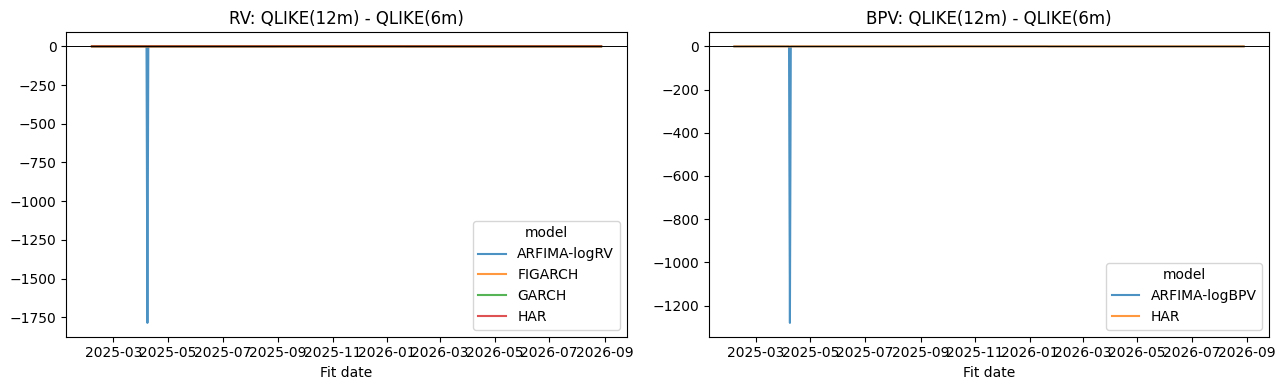

rows
model         target status                                     
ARFIMA-logBPV bpv    current_interval_boundary            314460
                     ok                                  6724420
                     predicted_interval_crosses_session   149600
ARFIMA-logRV  rv     current_interval_boundary            314460
                     ok                                  6724420
                     predicted_interval_crosses_session   149600
FIGARCH       rv     current_interval_boundary            314409
                     fit_failed                             1664
                     ok                                  6722823
                     predicted_interval_crosses_session   149584
GARCH         rv     current_interval_boundary            314460
                     ok                                  6724420
                     predicted_interval_crosses_session   149600
HAR           bpv    ok                                  7188480
              rv     ok                                  7188480

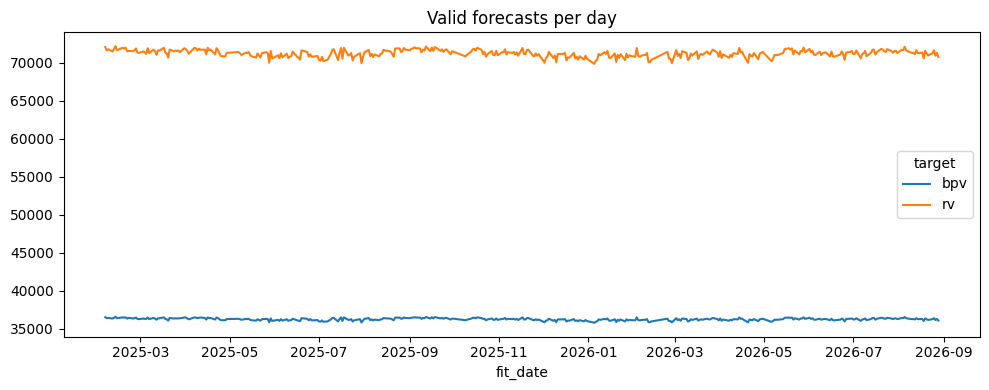

共同成功起点：下一步在同一轴/粒度内配对；15分钟跨所有配置配对。RV/BPV各自取交集。


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,common_origins,qlike,mse
569,validation_2025h1,money,5,60,6,HAR,rv,15m,93,15853,-11.130805,6.265939e-11
929,validation_2025h1,volume,5,60,6,HAR,rv,15m,93,15853,-11.130781,6.224615e-11
917,validation_2025h1,volume,5,30,6,HAR,rv,15m,93,15853,-11.129442,6.778619e-11
557,validation_2025h1,money,5,30,6,HAR,rv,15m,93,15853,-11.128589,6.749810e-11
749,validation_2025h1,time,5,60,6,HAR,rv,15m,93,15853,-11.127723,6.586938e-11
1049,validation_2025h1,volume,15,60,6,HAR,rv,15m,93,15853,-11.127463,6.145089e-11
593,validation_2025h1,money,5,360,6,HAR,rv,15m,93,15853,-11.127214,6.522044e-11
989,validation_2025h1,volume,10,60,6,HAR,rv,15m,93,15853,-11.127100,6.309552e-11
953,validation_2025h1,volume,5,360,6,HAR,rv,15m,93,15853,-11.127075,6.495359e-11
977,validation_2025h1,volume,10,30,6,HAR,rv,15m,93,15853,-11.126799,6.947927e-11


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,common_origins,qlike,mse
928,validation_2025h1,volume,5,60,6,HAR,bpv,15m,99,16890,-11.085289,6.560124e-11
568,validation_2025h1,money,5,60,6,HAR,bpv,15m,99,16890,-11.084450,6.608091e-11
748,validation_2025h1,time,5,60,6,HAR,bpv,15m,99,16890,-11.083938,7.478872e-11
952,validation_2025h1,volume,5,360,6,HAR,bpv,15m,99,16890,-11.083675,6.748986e-11
916,validation_2025h1,volume,5,30,6,HAR,bpv,15m,99,16890,-11.083675,7.432788e-11
592,validation_2025h1,money,5,360,6,HAR,bpv,15m,99,16890,-11.083544,6.790705e-11
556,validation_2025h1,money,5,30,6,HAR,bpv,15m,99,16890,-11.082812,7.369011e-11
988,validation_2025h1,volume,10,60,6,HAR,bpv,15m,99,16890,-11.081357,6.701027e-11
628,validation_2025h1,money,10,60,6,HAR,bpv,15m,99,16890,-11.081090,6.758030e-11
1048,validation_2025h1,volume,15,60,6,HAR,bpv,15m,99,16890,-11.080987,6.725424e-11


,clock,equivalent_minutes,model,target,predicted_variance,realized_variance,relative_error_bias,relative_error_lag1,event_progress,predicted_steps,actual_steps,information_age_minutes,prediction_to_actual
0,money,5,ARFIMA-logBPV,bpv,0.000015,0.00001,-0.220952,0.918890,0.499759,5.588234,5.637877,19.512398,1.519306
1,money,5,ARFIMA-logRV,rv,0.000011,0.00001,-0.045412,0.908473,0.499759,5.588234,5.637877,19.512398,1.076438
2,money,5,FIGARCH,rv,0.000008,0.00001,0.383655,0.933779,0.499762,5.587408,5.637056,19.512398,0.788843
3,money,5,GARCH,rv,0.000008,0.00001,0.375267,0.932749,0.499759,5.588234,5.637877,19.512398,0.765856
4,money,5,HAR,bpv,0.000011,0.00001,-0.039798,0.951085,NaN,NaN,NaN,19.512398,1.037832
5,money,5,HAR,rv,0.000010,0.00001,-0.033712,0.933067,NaN,NaN,NaN,19.512398,1.036444
6,money,10,ARFIMA-logBPV,bpv,0.000012,0.00001,-0.040512,0.933248,0.496850,2.793118,2.818938,36.137372,1.135397
7,money,10,ARFIMA-logRV,rv,0.000010,0.00001,0.010118,0.919728,0.496850,2.793118,2.818938,36.137372,1.043707
8,money,10,FIGARCH,rv,0.000009,0.00001,0.262114,0.933881,0.496850,2.793118,2.818938,36.137372,0.903670
9,money,10,GARCH,rv,0.000009,0.00001,0.260476,0.933922,0.496850,2.793118,2.818938,36.137372,0.892950


In [8]:
if daily_scores_df.empty:
    print("当前选择没有预测结果；检查日参数覆盖日期和运行配置。")
else:
    # 每种配置先在每日内部求平均，再跨日等权平均；高活动日不会因事件多而自动加权。
    summary_keys = ["fold_id","clock","equivalent_minutes","seasonality_lookback","fit_window_months","model","target","horizon"]
    forecast_summary_df = daily_scores_df.groupby(summary_keys,observed=True).agg(
        days=("fit_date","size"),origins=("origins","sum"),forecasts=("forecasts","sum"),
        qlike=("qlike","mean"),mse=("mse","mean"),
        mean_information_age_minutes=("information_age_minutes","mean"),
        forecast_seconds=("prediction_seconds","sum")).reset_index()
    forecast_summary_df["coverage"] = forecast_summary_df["forecasts"]/forecast_summary_df["origins"]
    # 这张表用各配置自身成功的起点做描述，覆盖率可能不同。
    # 公平比较应结合下方“共同成功起点”结果，而非直接把本表前几名当作最终结论。
    for target_name in ["rv","bpv"]:
        print(f"目标 {target_name.upper()}：日均损失；不同目标不得混排")
        display(forecast_summary_df.loc[forecast_summary_df["target"] == target_name].sort_values(
            ["fold_id","clock","equivalent_minutes","qlike"]).head(40))
    # 半年/一年严格在其他配置相同且两者均成功的起点上比较。
    # 12m减6m的损失差为负，才表示这一配对样本中一年窗口更好。
    if paired_score_frames:
        paired_daily_df = pd.concat(paired_score_frames,ignore_index=True)
        paired_summary_df = paired_daily_df.groupby(
            ["fold_id","clock","equivalent_minutes","seasonality_lookback","model","target"],observed=True).agg(
                days=("fit_date","size"),common_origins=("common_origins","sum"),
                qlike_12m_minus_6m=("qlike_12m_minus_6m","mean"),
                mse_12m_minus_6m=("mse_12m_minus_6m","mean")).reset_index()
        print("一年减半年：负值表示一年窗口较好，严格使用两窗共同起点。")
        display(paired_summary_df)
        figure,axes = plt.subplots(1,2,figsize=(13,4))
        for axis,target_name in zip(axes,["rv","bpv"]):
            plotted = paired_daily_df.loc[paired_daily_df["target"] == target_name].groupby(
                ["fit_date","model"])["qlike_12m_minus_6m"].mean().unstack("model")
            if len(plotted):
                plotted.plot(ax=axis,alpha=.8)
            axis.axhline(0,color="black",linewidth=.7)
            axis.set_title(f"{target_name.upper()}: QLIKE(12m) - QLIKE(6m)")
            axis.set_xlabel("Fit date")
        figure.tight_layout()
        plt.show()
    # 失败原因的频次帮助区分参数失败、特征缺失与时间转换边界。
    display(pd.concat(status_counts,ignore_index=True).groupby(["model","target","status"])["rows"].sum().to_frame())
    figure,axis = plt.subplots(figsize=(10,4))
    daily_scores_df.groupby(["fit_date","target"])["forecasts"].sum().unstack("target").plot(ax=axis)
    axis.set_title("Valid forecasts per day")
    figure.tight_layout()
    plt.show()

    # 本书的共同样本横跨所有所选clock/g/L/历史窗口/模型，RV和BPV分别取交集。
    # 某配置失败仍占配置数，可能使共同样本很少甚至为空；不能静默移除该配置。
    common_nonempty = [frame for frame in common_score_frames if not frame.empty]
    if common_nonempty:
        common_daily_df = pd.concat(common_nonempty,ignore_index=True)
        common_summary_df = common_daily_df.groupby(summary_keys,observed=True).agg(
            days=("fit_date","size"),common_origins=("forecasts","sum"),
            qlike=("qlike","mean"),mse=("mse","mean")).reset_index()
        print("共同成功起点：下一步在同一轴/粒度内配对；15分钟跨所有配置配对。RV/BPV各自取交集。")
        for target_name in ["rv","bpv"]:
            display(common_summary_df.loc[common_summary_df["target"].eq(target_name)].sort_values("qlike").head(30))
    else:
        print("当前配置没有全体共同成功起点；不能把覆盖范围不同的均值解释为公平排名。")

if not daily_scores_df.empty:
    # 以下是各配置自身覆盖样本的描述性校准与转换诊断，未重新按共同起点配对。
    # predicted_steps/actual_steps比较的是15分钟内活动量/阈值；HAR对应字段为NaN。
    # 残差是一分钟间隔的重叠15分钟标签误差，自相关不能当作独立样本显著性证据。
    calibration_df = daily_scores_df.groupby(["clock","equivalent_minutes","model","target"]).agg(
        predicted_variance=("mean_prediction","mean"),realized_variance=("mean_actual","mean"),
        relative_error_bias=("relative_error_bias","mean"),relative_error_lag1=("relative_error_lag1","mean"),
        event_progress=("event_progress","mean"),predicted_steps=("predicted_steps","mean"),
        actual_steps=("actual_steps","mean"),information_age_minutes=("information_age_minutes","mean")).reset_index()
    calibration_df["prediction_to_actual"] = calibration_df["predicted_variance"]/calibration_df["realized_variance"]
    display(calibration_df)


## 7. 方法依据与解释边界

[Patton（2011）](https://public.econ.duke.edu/~ap172/Patton_vol_proxies_JoE_2011.pdf) 讨论不完美波动代理下的预测比较。QLIKE／MSE 的代理稳健性质依赖条件无偏等假设，不会自动消除分钟插值与事件收益平方之间的口径差异。本研究将覆盖率、共同样本和尺度校准一并呈现。模型依据与参数还原假设见每日拟合 Notebook。

此前20个完整交易日的分时活动均值、完整事件的季节暴露比例分配，均为本研究明确冻结的基线转换假设；实际未来速度只用于诊断。


代理残差定义为 `actual / prediction − 1`，报告其偏差与日内一阶自相关。15 分钟标签存在重叠，自相关仅作诊断，不把分钟起点当作相互独立的显著性样本。